In [2]:
import os
import pandas as pd
from glob import glob
# ! pip install chardet

In [20]:
csv_roof = 'data/origin'
streetlights_df = pd.read_csv(f"{csv_roof}/suwon_street_lamp.csv", encoding='cp949')
streetlights_df.head()

,시군명,소재지도로명주소,소재지지번주소,위도,경도,설치연도,설치형태,관리부서명,관리기관전화번호,데이터기준일자
0,수원시,경기도 수원시 장안구 광교산로 154-25,경기도 수원시 장안구 연무동 산 1-4,37.301144,127.031677,2011.0,전용주,수원시 장안구,031-228-5486,2024-08-01
1,수원시,경기도 수원시 장안구 광교산로 148 신미주아파트,경기도 수원시 장안구 연무동 4-25,37.300966,127.031689,2011.0,전용주,수원시 장안구,031-228-5486,2024-08-01
2,수원시,경기도 수원시 장안구 광교산로 148 신미주아파트,경기도 수원시 장안구 연무동 4-25,37.301056,127.032004,2011.0,전용주,수원시 장안구,031-228-5486,2024-08-01
3,수원시,경기도 수원시 장안구 광교산로 148 신미주아파트,경기도 수원시 장안구 연무동 4-25,37.301155,127.032377,2011.0,전용주,수원시 장안구,031-228-5486,2024-08-01
4,수원시,경기도 수원시 장안구 광교산로 148 신미주아파트,경기도 수원시 장안구 연무동 4-25,37.301229,127.032653,2011.0,전용주,수원시 장안구,031-228-5486,2024-08-01


#### 전처리

In [21]:
# 3.4 영통구 필터링
streetlights_df = streetlights_df[streetlights_df['관리부서명'] == '수원시 영통구']

streetlights_df = streetlights_df[['소재지도로명주소', '위도', '경도', '설치연도']]
streetlights_df = streetlights_df.rename(columns={
    '소재지도로명주소': 'address',
    '위도': 'lat',
    '경도': 'lon',
    '설치연도': 'install_year'
})
streetlights_df['address'] = streetlights_df['address'].fillna('알 수 없음')
print(f'total streetlights: {len(streetlights_df)}')
# 3.5 결측치 제거
streetlights_df = streetlights_df.dropna(subset=['lat', 'lon','install_year'])
print(f'total streetlights: {len(streetlights_df)}')

total streetlights: 7569
total streetlights: 5237


In [22]:
# 3.5 설치연도 정수 변환
streetlights_df['install_year'] = streetlights_df['install_year'].astype(int)
# 3.6 상태 컬럼 추가 (데모용, 임의로 설정)
# 영통구 데이터만 남았으므로, 인덱스를 기준으로 임의 상태 부여
streetlights_df['status'] = '정상'
# 랜덤으로 몇개만 '고장' 넣기
import random
random.seed(42)
def random_status(row):
    if random.random() < 0.01:
        return '고장'
    else:
        return row['status']
streetlights_df['status'] = streetlights_df.apply(random_status, axis=1)

In [23]:
# ID는 순서로 'SL_0000' -> 'SL_9999'로 부여
streetlights_df['id'] = ['SL_' + str(i).zfill(4) for i in range(len(streetlights_df))]
streetlights_df = streetlights_df[['id', 'lat', 'lon', 'status',  'install_year']]
streetlights_df.to_csv('data/preprocessed/streetlights_data.csv', index=False, encoding='utf-8')

In [24]:
# 5. 결과 확인
print("=== 정제된 가로등 데이터 ===")
streetlights_df

=== 정제된 가로등 데이터 ===


,id,lat,lon,status,install_year
16404,SL_0000,37.280326,127.043026,정상,2014
16837,SL_0001,37.274215,127.037039,정상,2019
16838,SL_0002,37.274221,127.037416,정상,2019
16839,SL_0003,37.274264,127.037758,정상,2019
16840,SL_0004,37.274327,127.038180,정상,2019
...,...,...,...,...,...
24667,SL_5232,37.285576,127.055781,정상,2019
24668,SL_5233,37.285441,127.055961,정상,2019
24669,SL_5234,37.285319,127.056130,정상,2019
24670,SL_5235,37.285049,127.055887,정상,2019


---
#### 이상 좌표들 제거 (좌표 기준으로, 영통구 아닌거 쳐내기)

  ADM_SECT_C       SGG_NM  SGG_OID COL_ADM_SE  \
5      41117  경기도 수원시 영통구   3618.0      41110   

                                            geometry  
5  POLYGON ((204161.482 524190.053, 204212.658 52...  


<Axes: >

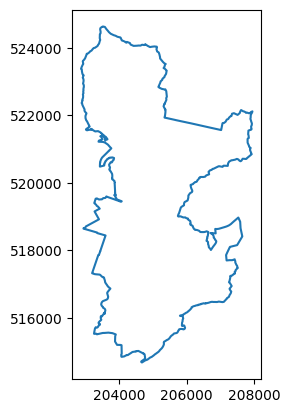

In [93]:
import geopandas as gpd

# 1) 동 경계 불러오기 (EPSG:4326 → 투영좌표계(e.g. EPSG:5179)로 변환)
fp = "/home/nute11a/workspace/PBL/SUWON/code/data/origin/LARD_ADM_SECT_SGG_41_202505.shp"
gdf = gpd.read_file(fp, engine="pyogrio")


mask = gdf['SGG_NM'] == '경기도 수원시 영통구'
sgg = gdf[mask]
sgg.to_csv('data/preprocessed/suwon_yeongtong_boundary.csv', index=False, encoding='utf-8')
print(sgg)
sgg.boundary.plot()

In [30]:
streetlights_df

,id,lat,lon,status,install_year
16404,SL_0000,37.280326,127.043026,정상,2014
16837,SL_0001,37.274215,127.037039,정상,2019
16838,SL_0002,37.274221,127.037416,정상,2019
16839,SL_0003,37.274264,127.037758,정상,2019
16840,SL_0004,37.274327,127.038180,정상,2019
...,...,...,...,...,...
24667,SL_5232,37.285576,127.055781,정상,2019
24668,SL_5233,37.285441,127.055961,정상,2019
24669,SL_5234,37.285319,127.056130,정상,2019
24670,SL_5235,37.285049,127.055887,정상,2019


In [35]:
from shapely.geometry import Point

df = streetlights_df  # 예: pd.read_csv(...) 등
gdf_pts = gpd.GeoDataFrame(
    df,
    geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])],
    crs = "EPSG:4326"  # your pts가 위경도(WGS84)라면
)

sgg = sgg.to_crs(gdf_pts.crs)

# 3a) within() 메서드 사용하기
#    polygon 단일객체로 합친 다음, pts가 그 안에 있는지 확인
muni_poly = sgg.unary_union
mask = gdf_pts.within(muni_poly)
pts_in_muni = gdf_pts[mask]

# 3b) 또는 공간 조인(spatial join) 사용하기
pts_in_muni = gpd.sjoin(
    gdf_pts, sgg[['geometry']], 
    how="inner", 
    predicate='within'
).drop(columns='index_right')

# 결과: pts_in_muni 에 영통구 경계 안에 있는 점들만 남습니다.
print(len(gdf_pts), ' -> ', len(pts_in_muni))
pts_in_muni.to_csv('data/preprocessed/streetlights_data2.csv', index=False, encoding='utf-8')
pts_in_muni.head(3)

5237  ->  5134


,id,lat,lon,status,install_year,geometry
16404,SL_0000,37.280326,127.043026,정상,2014,POINT (127.04303 37.28033)
16837,SL_0001,37.274215,127.037039,정상,2019,POINT (127.03704 37.27421)
16838,SL_0002,37.274221,127.037416,정상,2019,POINT (127.03742 37.27422)


<Axes: >

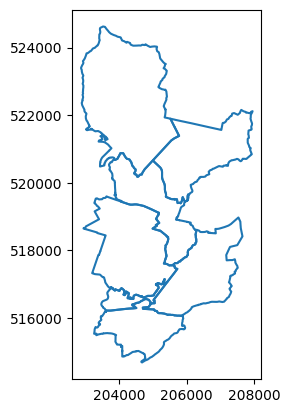

In [71]:
# 1) 동 경계 불러오기 (EPSG:4326 → 투영좌표계(e.g. EPSG:5179)로 변환)
fp = "data/origin/LX_EMD/EMD.shp"
gdfd = gpd.read_file(fp, engine="pyogrio")
# 수원시 영통구 들어간 데이터만 필터링
mask = gdfd['adzn_nm'].str.contains('영통구')
dong_geo = gdfd[mask]
# rename : emd_nm -> dong_name
dong_geo = dong_geo.rename(columns={'emd_nm': 'dong_name'})
dong_geo.boundary.plot()

In [72]:
dong_geo.head()

,adzn_nm,emd_cd,dong_name,geometry
1254,경기도 수원시 영통구 매탄동,41117101,매탄동,"POLYGON ((204052.957 519443.572, 204051.696 51..."
1255,경기도 수원시 영통구 원천동,41117102,원천동,"POLYGON ((204298.885 520693.753, 204354.259 52..."
1256,경기도 수원시 영통구 망포동,41117107,망포동,"POLYGON ((204941.749 516446.940, 204946.344 51..."
1427,경기도 수원시 영통구 신동,41117106,신동,"POLYGON ((205311.811 517006.340, 205311.872 51..."
1431,경기도 수원시 영통구 영통동,41117105,영통동,"POLYGON ((207601.183 518643.035, 207632.469 51..."


In [84]:
df = pd.read_csv('data/preprocessed/streetlights_data2.csv')
g_lights = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
).to_crs(epsg=5179)

g_lights = g_lights.to_crs(dong_geo.crs)
lights_with_dong = gpd.sjoin(
    g_lights,
    dong_geo[["dong_name", "geometry"]],
    how="left",            # 폴리곤에 속하지 않는 점도 남기려면 "left"
    predicate="within"     # 포인트가 폴리곤 안에 있는 경우
).drop(columns="index_right")

# 5) 결과 확인
lights_with_dong.head()

,id,lat,lon,status,install_year,geometry,dong_name
0,SL_0000,37.280326,127.043026,정상,2014,POINT (203815.711 520124.479),원천동
1,SL_0001,37.274215,127.037039,정상,2019,POINT (203285.026 519446.038),매탄동
2,SL_0002,37.274221,127.037416,정상,2019,POINT (203318.462 519446.717),매탄동
3,SL_0003,37.274264,127.037758,정상,2019,POINT (203348.793 519451.502),매탄동
4,SL_0004,37.274327,127.038180,정상,2019,POINT (203386.218 519458.509),매탄동


In [ ]:
lights_with_dong.to_csv('data/preprocessed/streetlights_data3.csv', index=False, encoding='utf-8')

In [91]:
# 4) 동별 가로등 개수 집계
counts = lights_with_dong.groupby('dong_name').size().rename('light_count')
# 5) 동별 면적 계산 (km²)
dong_geo['area_km2'] = dong_geo.geometry.area / 1e6
# 6) 밀도 계산
stats = dong_geo.set_index('dong_name').join(counts).fillna(0)
stats['density'] = stats['light_count'] / stats['area_km2']

stats = stats.reset_index()
stats.to_csv('data/preprocessed/dong_stats.csv', index=False, encoding='utf-8')
# geometriy 제외한 결과도 따로 저장
stats[['dong_name', 'light_count', 'area_km2', 'density']].to_csv('data/preprocessed/dong_stats_no_geometry.csv', index=False, encoding='utf-8')
# 7) 결과 확인
stats

,dong_name,adzn_nm,emd_cd,geometry,area_km2,light_count,density
0,매탄동,경기도 수원시 영통구 매탄동,41117101,"POLYGON ((204052.957 519443.572, 204051.696 51...",5.134353,750,146.074880
1,원천동,경기도 수원시 영통구 원천동,41117102,"POLYGON ((204298.885 520693.753, 204354.259 52...",3.238625,631,194.835779
2,망포동,경기도 수원시 영통구 망포동,41117107,"POLYGON ((204941.749 516446.940, 204946.344 51...",2.579897,693,268.615401
3,신동,경기도 수원시 영통구 신동,41117106,"POLYGON ((205311.811 517006.340, 205311.872 51...",0.602946,300,497.556623
4,영통동,경기도 수원시 영통구 영통동,41117105,"POLYGON ((207601.183 518643.035, 207632.469 51...",4.029898,1093,271.222762
5,이의동,경기도 수원시 영통구 이의동,41117103,"POLYGON ((204163.374 524184.131, 204214.529 52...",7.982972,1172,146.812494
6,하동,경기도 수원시 영통구 하동,41117104,"POLYGON ((207752.143 522081.215, 207760.578 52...",4.166777,474,113.756976
